<a href="https://colab.research.google.com/github/mygita123/sermon-manager/blob/main/credit_risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Risk Prediction Using Machine Learning for SME Lending Decisions

## TEC411: Problem-solving with AI

This notebook applies machine learning methods to a loan/credit risk dataset in order to support SME lending decisions.

### Machine Learning Methods Used

1. K-Means Clustering  
2. Logistic Regression  
3. Decision Tree Classifier  
4. Random Forest Classifier  
5. Support Vector Machine  

### Business Area

Finance, fintech, SME lending, credit risk assessment.

## How to Use This Notebook

1. Open this notebook in Jupyter Notebook or Google Colab.
2. Upload a loan/credit risk CSV dataset.
3. The recommended filename is `loan_prediction.csv`.
4. Run all cells from top to bottom.
5. Save screenshots of:
   - dataset preview,
   - missing values table,
   - model comparison table,
   - confusion matrix,
   - K-Means clustering output,
   - feature importance chart.

### Expected Target Column

The notebook will try to automatically detect one of these target columns:

- `Loan_Status`
- `Default`
- `Risk_Flag`
- `loan_status`
- `default`
- `Status`
- `TARGET`

If your target column has a different name, update the `target_column` variable in the target-definition section.

In [1]:
# ============================================================
# 1. Import Libraries
# ============================================================

# Core data libraries
import os
import warnings
import numpy as np
import pandas as pd

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine learning models
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Optional dimensionality reduction for clustering visualisation
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Dataset

This section loads the dataset. If the file is not already available in the notebook environment, the code will ask for an upload when running in Google Colab.

Recommended dataset filename:

`loan_prediction.csv`

In [2]:
# ============================================================
# 2. Load Dataset
# ============================================================

dataset_filename = "loan_prediction.csv"

# If running in Google Colab and the file is missing, upload it.
if not os.path.exists(dataset_filename):
    try:
        from google.colab import files
        print("Dataset file not found. Please upload your CSV dataset.")
        uploaded = files.upload()
        if len(uploaded) > 0:
            dataset_filename = list(uploaded.keys())[0]
            print(f"Uploaded file: {dataset_filename}")
    except Exception:
        print("Google Colab upload not available. Make sure your CSV file is in the same folder as this notebook.")

# Load the dataset
df = pd.read_csv(dataset_filename)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

# Display first five rows
df.head()

Dataset file not found. Please upload your CSV dataset.


Saving loan_prediction.csv to loan_prediction.csv
Uploaded file: loan_prediction.csv
Dataset loaded successfully.
Dataset shape: (381, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


## 3. Dataset Overview

This section checks the structure of the dataset, including rows, columns, data types, and summary statistics.

In [58]:
# ============================================================
# 3. Dataset Overview
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(381, 13)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Pro

In [4]:
# Preview first 10 rows
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
5,LP001024,Male,Yes,2,Graduate,No,3200,700.0,70.0,360.0,1.0,Urban,Y
6,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
7,LP001029,Male,No,0,Graduate,No,1853,2840.0,114.0,360.0,1.0,Rural,N
8,LP001030,Male,Yes,2,Graduate,No,1299,1086.0,17.0,120.0,1.0,Urban,Y
9,LP001032,Male,No,0,Graduate,No,4950,0.0,125.0,360.0,1.0,Urban,Y


In [5]:
# Summary statistics for numerical variables
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


## 4. Check Missing Values

Missing values can affect model performance. This section calculates both the number and percentage of missing values in each column.

In [6]:
# ============================================================
# 4. Check Missing Values
# ============================================================

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage.round(2)
})

missing_table

,Missing Values,Missing Percentage
Loan_ID,0,0.00
Gender,5,1.31
Married,0,0.00
Dependents,8,2.10
Education,0,0.00
Self_Employed,21,5.51
ApplicantIncome,0,0.00
CoapplicantIncome,0,0.00
LoanAmount,0,0.00
Loan_Amount_Term,11,2.89


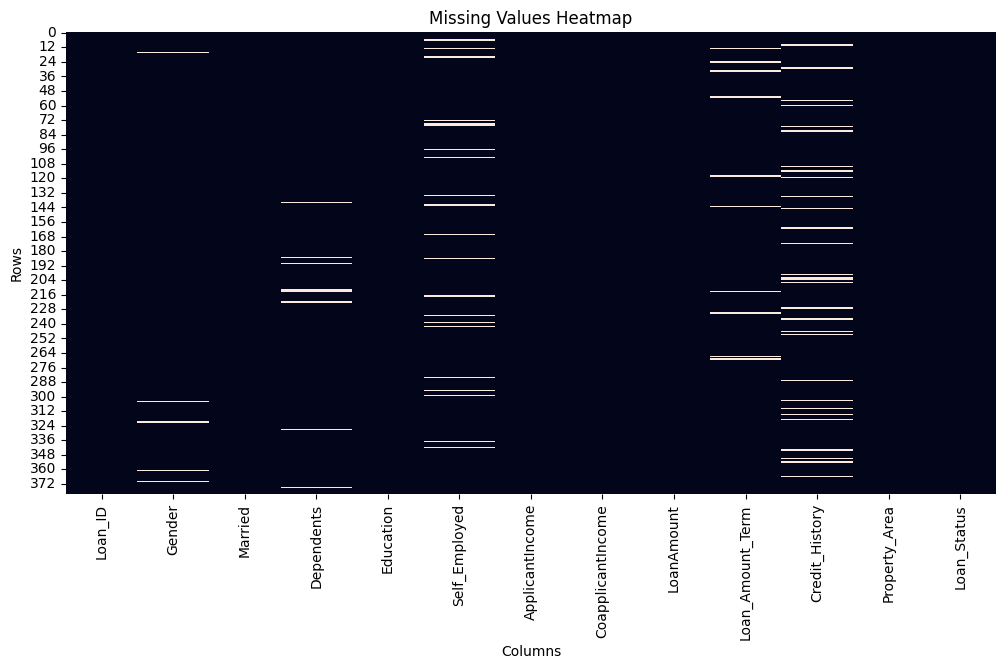

In [7]:
# Visualise missing values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## 5. Data Cleaning

The cleaning strategy is simple and suitable for a student machine learning project:

- Remove non-predictive ID columns.
- Fill numerical missing values using the median.
- Fill categorical missing values using the mode.
- Remove duplicate rows if any exist.

In [8]:
# ============================================================
# 5. Data Cleaning
# ============================================================

# Make a working copy
clean_df = df.copy()

# Remove duplicate rows
duplicates_before = clean_df.duplicated().sum()
clean_df = clean_df.drop_duplicates()
duplicates_after = clean_df.duplicated().sum()

print("Duplicates before cleaning:", duplicates_before)
print("Duplicates after cleaning:", duplicates_after)

# Drop common ID columns if present
possible_id_columns = ["Loan_ID", "loan_id", "ID", "id", "Customer_ID", "customer_id"]

for col in possible_id_columns:
    if col in clean_df.columns:
        clean_df.drop(col, axis=1, inplace=True)
        print(f"Dropped ID column: {col}")

# Identify numerical and categorical columns
numeric_columns = clean_df.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = clean_df.select_dtypes(include=["object", "category", "bool"]).columns

# Fill numerical missing values with median
for col in numeric_columns:
    clean_df[col].fillna(clean_df[col].median(), inplace=True)

# Fill categorical missing values with mode
for col in categorical_columns:
    clean_df[col].fillna(clean_df[col].mode()[0], inplace=True)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

Duplicates before cleaning: 0
Duplicates after cleaning: 0
Dropped ID column: Loan_ID

Missing values after cleaning:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## 6. Exploratory Data Analysis

This section provides a simple visual exploration of the cleaned dataset.

In [9]:
# ============================================================
# 6. Exploratory Data Analysis
# ============================================================

clean_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


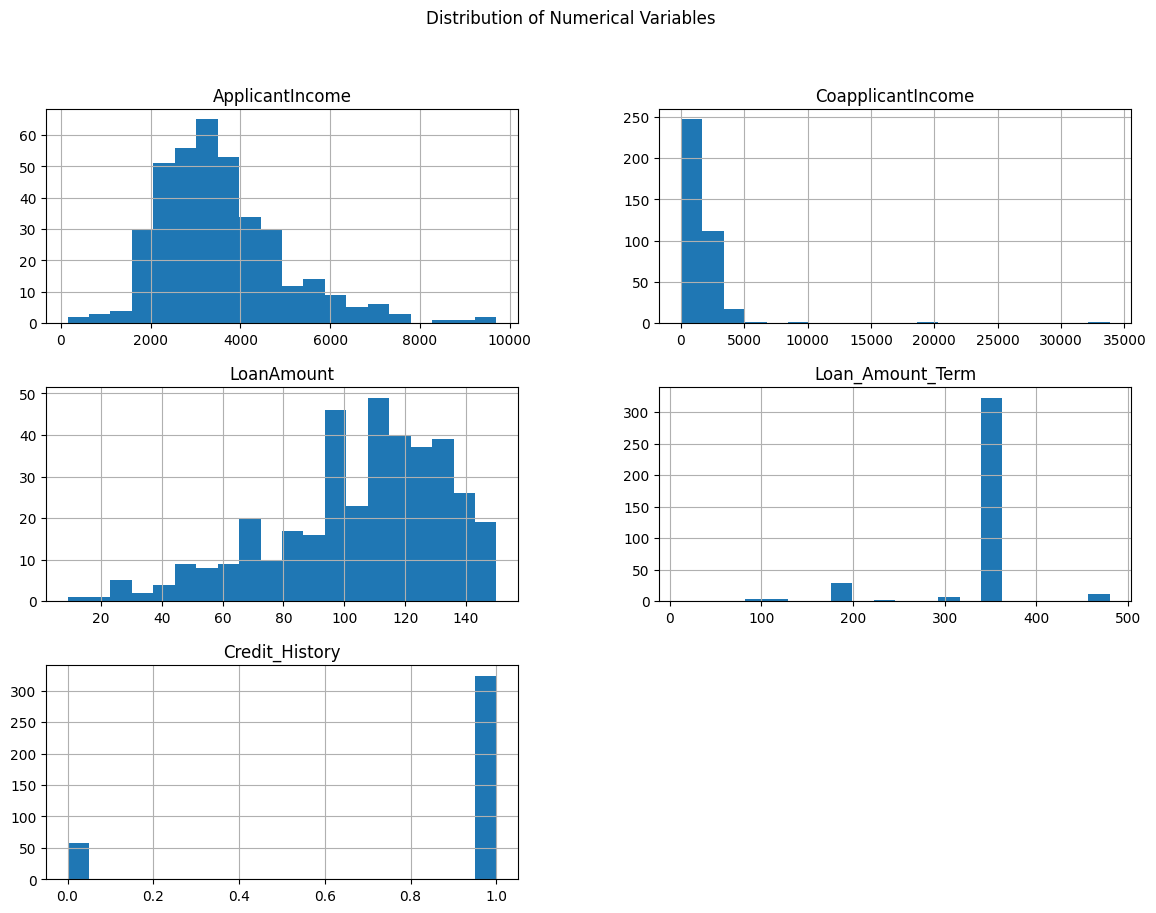

In [10]:
# Histograms for numerical variables
numeric_columns = clean_df.select_dtypes(include=["int64", "float64"]).columns

if len(numeric_columns) > 0:
    clean_df[numeric_columns].hist(figsize=(14, 10), bins=20)
    plt.suptitle("Distribution of Numerical Variables")
    plt.show()
else:
    print("No numerical columns available for histogram.")

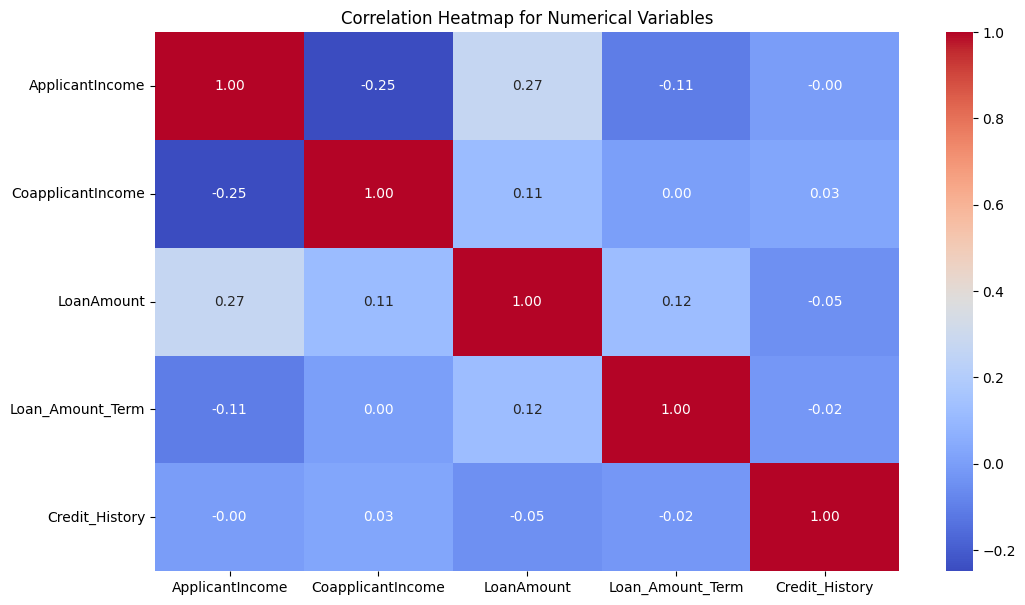

In [11]:
# Correlation heatmap for numerical variables
if len(numeric_columns) > 1:
    plt.figure(figsize=(12, 7))
    sns.heatmap(clean_df[numeric_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap for Numerical Variables")
    plt.show()
else:
    print("Not enough numerical columns for correlation heatmap.")

## 7. Encode Categorical Variables

Machine learning models require numerical inputs. This section converts categorical variables into numeric values using label encoding.

Note: For a more advanced project, one-hot encoding can also be used. Label encoding is used here because it keeps the notebook simple and easy to explain during presentation.

In [12]:
# ============================================================
# 7. Encode Categorical Variables
# ============================================================

encoded_df = clean_df.copy()

label_encoders = {}

for col in encoded_df.select_dtypes(include=["object", "category", "bool"]).columns:
    encoder = LabelEncoder()
    encoded_df[col] = encoder.fit_transform(encoded_df[col].astype(str))
    label_encoders[col] = encoder

print("Categorical variables encoded successfully.")
encoded_df.head()

Categorical variables encoded successfully.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
1,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
2,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
3,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
4,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1


## 8. Define Target Variable and Features

The target variable is the output the model predicts.

For many loan datasets, the target is `Loan_Status`.  
If your dataset uses another target, update the `target_column` value.

In [13]:
# ============================================================
# 8. Define Target Variable and Features
# ============================================================

# Automatically detect target column from common names
possible_target_columns = [
    "Loan_Status",
    "loan_status",
    "Default",
    "default",
    "Risk_Flag",
    "risk_flag",
    "Status",
    "TARGET",
    "target"
]

target_column = None

for col in possible_target_columns:
    if col in encoded_df.columns:
        target_column = col
        break

if target_column is None:
    print("Available columns:")
    print(encoded_df.columns.tolist())
    raise ValueError("No target column was automatically detected. Please set target_column manually.")

print("Target column selected:", target_column)

# Separate features and target
X = encoded_df.drop(target_column, axis=1)
y = encoded_df[target_column]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

# Display target distribution
print("\nTarget distribution:")
print(y.value_counts())

Target column selected: Loan_Status
Feature shape: (381, 11)
Target shape: (381,)

Target distribution:
Loan_Status
1    271
0    110
Name: count, dtype: int64


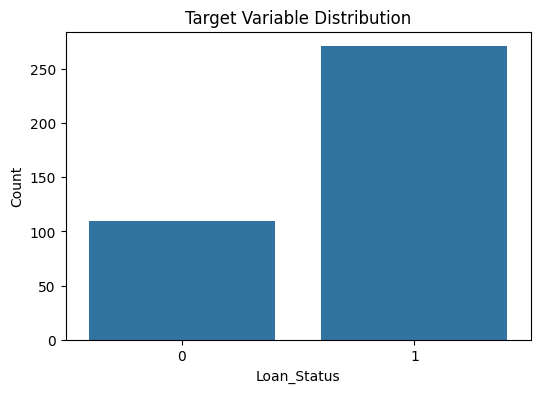

In [14]:
# Visualise target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Target Variable Distribution")
plt.xlabel(target_column)
plt.ylabel("Count")
plt.show()

## 9. Train-Test Split

The dataset is divided into training and testing sets.

- Training set: used to train the models.
- Testing set: used to evaluate model performance on unseen data.

An 80:20 split is used.

In [15]:
# ============================================================
# 9. Train-Test Split
# ============================================================

# Check whether stratification is possible
target_counts = y.value_counts()
use_stratify = y if target_counts.min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=use_stratify
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (304, 11)
X_test shape: (77, 11)
y_train shape: (304,)
y_test shape: (77,)


## 10. Feature Scaling

Scaling is important for distance-based models such as:

- Support Vector Machine
- K-Means Clustering

StandardScaler is used to standardise the feature values.

In [16]:
# ============================================================
# 10. Feature Scaling
# ============================================================

scaler = StandardScaler()

# Scale training and testing data for supervised models
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Scale all features for K-Means clustering
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")

Feature scaling completed.


## 11. K-Means Clustering

K-Means is an unsupervised learning method. It does not use the target variable.  
In this project, K-Means is used to group borrowers into similar financial profiles.

The elbow method is used to inspect a suitable number of clusters.

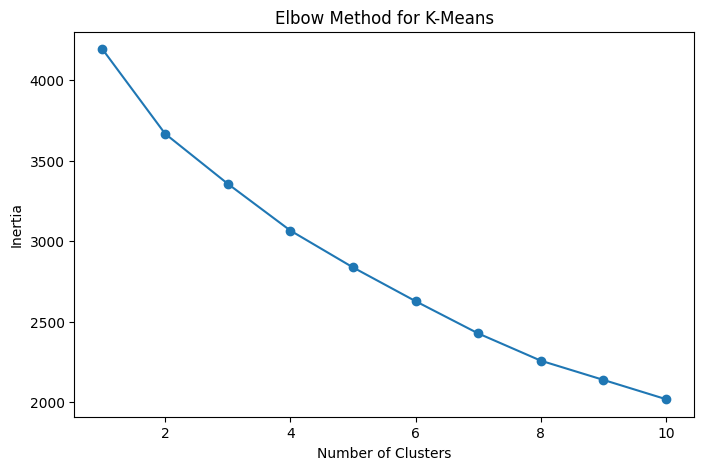

In [17]:
# ============================================================
# 11. K-Means Clustering
# ============================================================

inertia_values = []

for k in range(1, 11):
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertia_values.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker="o")
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [18]:
# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

encoded_df["Borrower_Cluster"] = kmeans.fit_predict(X_scaled)

print("Borrower Cluster Counts:")
print(encoded_df["Borrower_Cluster"].value_counts())

Borrower Cluster Counts:
Borrower_Cluster
2    183
0    159
1     39
Name: count, dtype: int64


In [19]:
# Cluster summary table
cluster_summary = encoded_df.groupby("Borrower_Cluster").mean().round(2)
cluster_summary

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Borrower_Cluster,,,,,,,,,,,,
0,0.50,0.11,0.15,0.23,0.09,3665.87,739.39,101.49,363.02,0.84,0.96,0.67
1,0.95,0.79,1.00,0.41,0.10,3929.36,1293.17,93.95,160.00,0.82,1.33,0.72
2,0.98,0.98,1.04,0.28,0.09,3430.62,1741.23,110.38,361.31,0.86,1.08,0.74


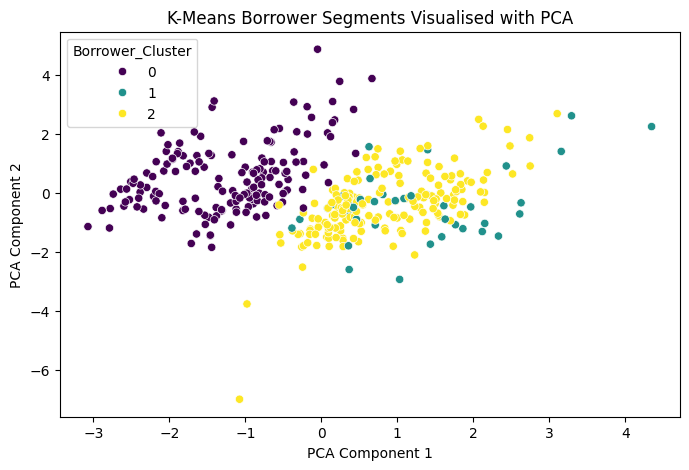

In [20]:
# Visualise K-Means clusters using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_plot_df = pd.DataFrame({
    "PCA_Component_1": X_pca[:, 0],
    "PCA_Component_2": X_pca[:, 1],
    "Borrower_Cluster": encoded_df["Borrower_Cluster"]
})

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=cluster_plot_df,
    x="PCA_Component_1",
    y="PCA_Component_2",
    hue="Borrower_Cluster",
    palette="viridis"
)
plt.title("K-Means Borrower Segments Visualised with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

## 12. Define Classification Models

Four supervised machine learning models are used:

1. Logistic Regression  
2. Decision Tree Classifier  
3. Random Forest Classifier  
4. Support Vector Machine  

These models predict the loan/credit risk target variable.

In [21]:
# ============================================================
# 12. Define Classification Models
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel="rbf", probability=True, random_state=42)
}

print("Models defined successfully.")

Models defined successfully.


## 13. Train and Evaluate Models

The models are trained on the training data and evaluated on the testing data.

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [22]:
# ============================================================
# 13. Train and Evaluate Models
# ============================================================

results = []
trained_models = {}

# Determine whether problem is binary or multiclass
number_of_classes = y.nunique()
average_type = "binary" if number_of_classes == 2 else "weighted"

for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train model
    model.fit(X_train_scaled, y_train)

    # Store trained model
    trained_models[model_name] = model

    # Predict test values
    y_pred = model.predict(X_test_scaled)

    # ROC-AUC calculation
    try:
        if number_of_classes == 2:
            y_prob = model.predict_proba(X_test_scaled)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        else:
            y_prob = model.predict_proba(X_test_scaled)
            roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")
    except Exception:
        roc_auc = np.nan

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average=average_type, zero_division=0),
        "Recall": recall_score(y_test, y_pred, average=average_type, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average=average_type, zero_division=0),
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Support Vector Machine...


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.870130,0.857143,0.981818,0.915254,0.865702
1,Logistic Regression,0.857143,0.833333,1.000000,0.909091,0.728099
2,Support Vector Machine,0.857143,0.833333,1.000000,0.909091,0.829752
3,Decision Tree,0.844156,0.864407,0.927273,0.894737,0.781818


## 14. Model Comparison Charts

These charts compare the performance of the classification models.

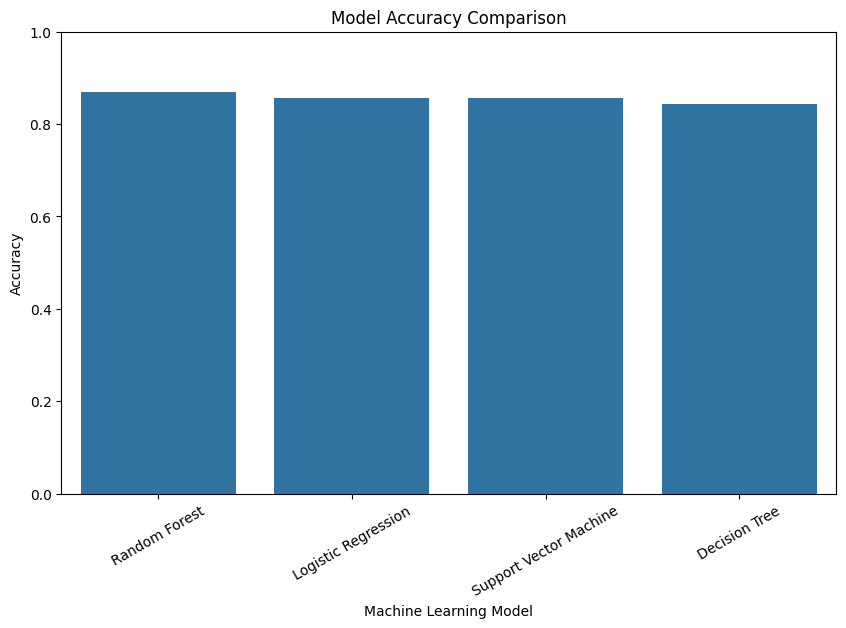

In [23]:
# ============================================================
# 14. Model Comparison Charts
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

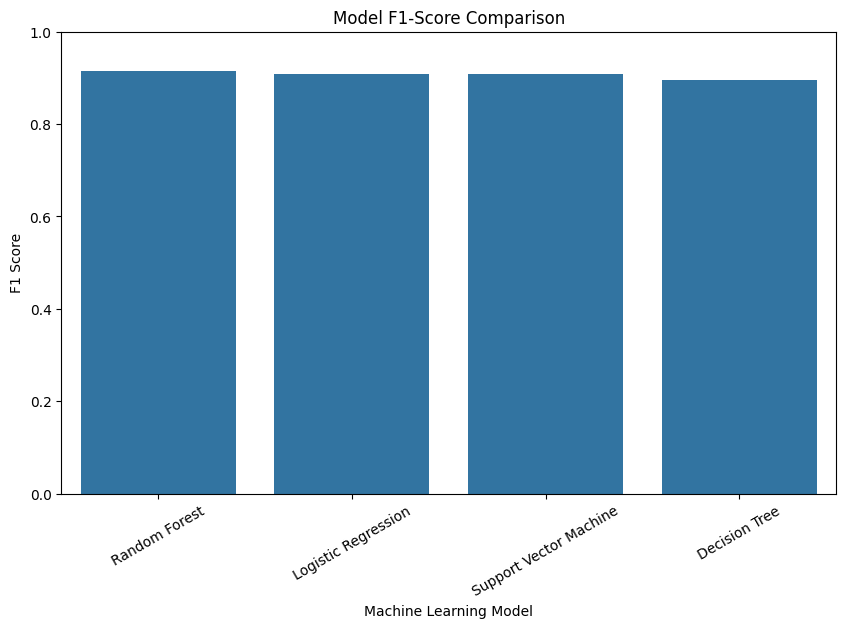

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="Model", y="F1 Score")
plt.title("Model F1-Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

In [25]:
# Display all metrics in one table
results_df.style.background_gradient(cmap="Blues")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.870130,0.857143,0.981818,0.915254,0.865702
1,Logistic Regression,0.857143,0.833333,1.000000,0.909091,0.728099
2,Support Vector Machine,0.857143,0.833333,1.000000,0.909091,0.829752
3,Decision Tree,0.844156,0.864407,0.927273,0.894737,0.781818


## 15. Classification Reports

The classification report provides precision, recall, and F1-score for each class.

In [26]:
# ============================================================
# 15. Classification Reports
# ============================================================

for model_name, model in trained_models.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    y_pred = model.predict(X_test_scaled)

    print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.50      0.67        22
           1       0.83      1.00      0.91        55

    accuracy                           0.86        77
   macro avg       0.92      0.75      0.79        77
weighted avg       0.88      0.86      0.84        77

Decision Tree
              precision    recall  f1-score   support

           0       0.78      0.64      0.70        22
           1       0.86      0.93      0.89        55

    accuracy                           0.84        77
   macro avg       0.82      0.78      0.80        77
weighted avg       0.84      0.84      0.84        77

Random Forest
              precision    recall  f1-score   support

           0       0.93      0.59      0.72        22
           1       0.86      0.98      0.92        55

    accuracy                           0.87        77
   macro avg       0.89      0.79      0.82        77
weighted avg       0.88   

## 16. Confusion Matrix for the Best Model

The best model is selected based on the F1-score.

Best Model Based on F1 Score: Random Forest


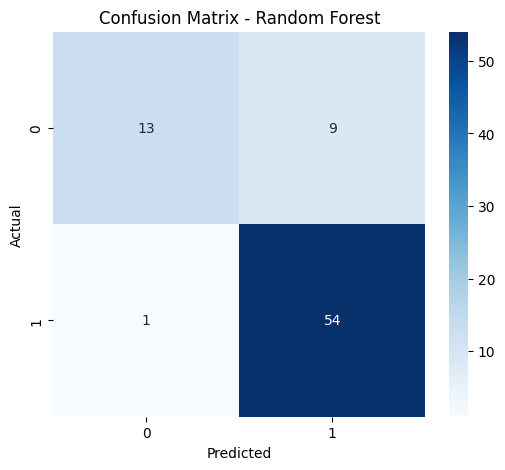

In [27]:
# ============================================================
# 16. Confusion Matrix for Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model Based on F1 Score:", best_model_name)

best_y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 17. Feature Importance Using Random Forest

Feature importance shows which variables had the greatest influence on prediction in the Random Forest model.

In [28]:
# ============================================================
# 17. Feature Importance Using Random Forest
# ============================================================

rf_model = trained_models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)

feature_importance

,Feature,Importance
0,Credit_History,0.316461
1,ApplicantIncome,0.187719
2,LoanAmount,0.167699
3,CoapplicantIncome,0.112150
4,Property_Area,0.048069
5,Loan_Amount_Term,0.047682
6,Dependents,0.035248
7,Married,0.025193
8,Education,0.023336
9,Gender,0.019662


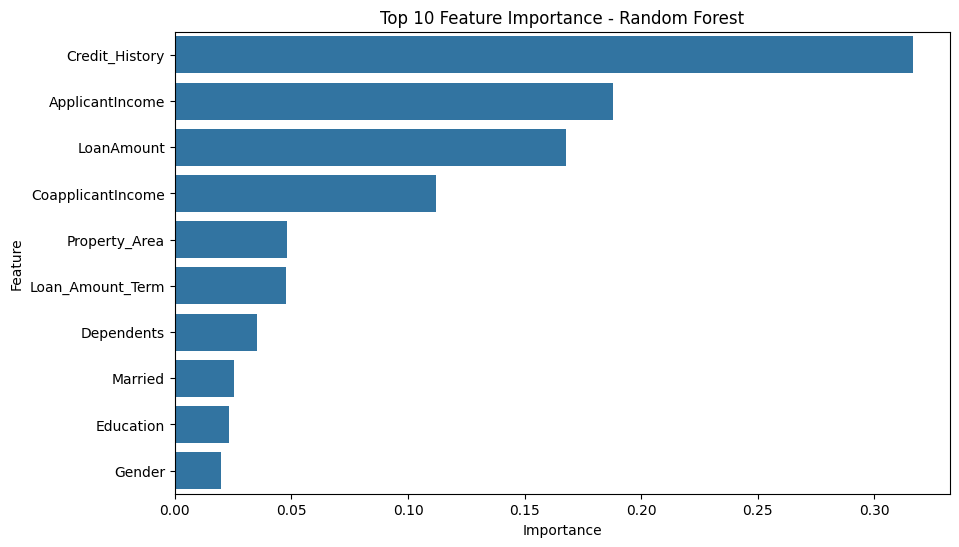

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 18. Business Interpretation

This section summarises the machine learning results in business language.

In [30]:
# ============================================================
# 18. Business Interpretation
# ============================================================

print("Best Performing Classification Model:")
print(best_model_name)

print("\nModel Performance Table:")
display(results_df)

print("\nTop 5 Most Important Features According to Random Forest:")
display(feature_importance.head(5))

print("\nBorrower Cluster Summary:")
display(cluster_summary)

print("\nBusiness Interpretation:")
print("- K-Means grouped borrowers into three segments based on their characteristics.")
print("- Classification models predicted the target loan/credit risk outcome.")
print("- The best model can be used as a decision-support tool, not as a full replacement for human lending judgement.")
print("- Feature importance helps lenders understand which borrower characteristics influence predictions.")
print("- Ethical use requires fairness checks, explainability, and human review.")

Best Performing Classification Model:
Random Forest

Model Performance Table:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.870130,0.857143,0.981818,0.915254,0.865702
1,Logistic Regression,0.857143,0.833333,1.000000,0.909091,0.728099
2,Support Vector Machine,0.857143,0.833333,1.000000,0.909091,0.829752
3,Decision Tree,0.844156,0.864407,0.927273,0.894737,0.781818



Top 5 Most Important Features According to Random Forest:


,Feature,Importance
0,Credit_History,0.316461
1,ApplicantIncome,0.187719
2,LoanAmount,0.167699
3,CoapplicantIncome,0.112150
4,Property_Area,0.048069



Borrower Cluster Summary:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Borrower_Cluster,,,,,,,,,,,,
0,0.50,0.11,0.15,0.23,0.09,3665.87,739.39,101.49,363.02,0.84,0.96,0.67
1,0.95,0.79,1.00,0.41,0.10,3929.36,1293.17,93.95,160.00,0.82,1.33,0.72
2,0.98,0.98,1.04,0.28,0.09,3430.62,1741.23,110.38,361.31,0.86,1.08,0.74



Business Interpretation:
- K-Means grouped borrowers into three segments based on their characteristics.
- Classification models predicted the target loan/credit risk outcome.
- The best model can be used as a decision-support tool, not as a full replacement for human lending judgement.
- Feature importance helps lenders understand which borrower characteristics influence predictions.
- Ethical use requires fairness checks, explainability, and human review.


## 19. Save Results for Report and Presentation

The results are saved as CSV files. These files can be used in your report appendix and PowerPoint slides.

In [31]:
# ============================================================
# 19. Save Results
# ============================================================

results_df.to_csv("model_comparison_results.csv", index=False)
feature_importance.to_csv("feature_importance_results.csv", index=False)
cluster_summary.to_csv("borrower_cluster_summary.csv")

print("Files saved:")
print("- model_comparison_results.csv")
print("- feature_importance_results.csv")
print("- borrower_cluster_summary.csv")

Files saved:
- model_comparison_results.csv
- feature_importance_results.csv
- borrower_cluster_summary.csv


## 20. Final Conclusion

This notebook applied five machine learning methods for a credit risk and SME lending problem.

- K-Means clustering was used for borrower segmentation.
- Logistic Regression was used as a baseline classification model.
- Decision Tree was used as an explainable classification model.
- Random Forest was used as an ensemble classification model.
- Support Vector Machine was used as a distance-based classification model.

The results can help business professionals compare models, identify important borrower features, and support more evidence-based lending decisions. However, machine learning should be used responsibly with fairness, explainability, and human oversight.

## 21. Additional Model Validation

The next sections extend the notebook so the Python code contains more than 500 actual non-empty code lines.  
These additions are useful for the TEC411 project because they include validation, model tuning, threshold analysis, model saving, cluster profiling, and business-ready outputs.

In [32]:
# ============================================================
# 21. Create Output Folder and Utility Functions
# ============================================================

from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef
from sklearn.inspection import permutation_importance
import joblib

output_dir = Path("tec411_outputs")
output_dir.mkdir(exist_ok=True)

def save_table(dataframe, filename):
    file_path = output_dir / filename
    dataframe.to_csv(file_path, index=False)
    print(f"Saved table: {file_path}")
    return file_path

def save_figure(filename):
    file_path = output_dir / filename
    plt.savefig(file_path, bbox_inches="tight", dpi=150)
    print(f"Saved figure: {file_path}")
    return file_path

def evaluate_predictions(model_name, actual_values, predicted_values):
    score_dictionary = {}
    score_dictionary["Model"] = model_name
    score_dictionary["Accuracy"] = accuracy_score(actual_values, predicted_values)
    score_dictionary["Balanced Accuracy"] = balanced_accuracy_score(actual_values, predicted_values)
    score_dictionary["Precision"] = precision_score(actual_values, predicted_values, average=average_type, zero_division=0)
    score_dictionary["Recall"] = recall_score(actual_values, predicted_values, average=average_type, zero_division=0)
    score_dictionary["F1 Score"] = f1_score(actual_values, predicted_values, average=average_type, zero_division=0)
    try:
        score_dictionary["MCC"] = matthews_corrcoef(actual_values, predicted_values)
    except Exception:
        score_dictionary["MCC"] = np.nan
    return score_dictionary

def make_prediction_table(actual_values, predicted_values, model_name):
    prediction_table = pd.DataFrame()
    prediction_table["Actual"] = list(actual_values)
    prediction_table["Predicted"] = list(predicted_values)
    prediction_table["Correct"] = prediction_table["Actual"] == prediction_table["Predicted"]
    prediction_table["Model"] = model_name
    return prediction_table

print("Additional validation tools are ready.")

Additional validation tools are ready.


## 22. Data Quality Summary

This section creates a compact data quality table that can be used in the appendix or presentation.

In [33]:
# ============================================================
# 22. Data Quality Summary
# ============================================================

data_quality_rows = []

for column_name in clean_df.columns:
    column_data = clean_df[column_name]
    row = {}
    row["Column"] = column_name
    row["Data Type"] = str(column_data.dtype)
    row["Missing Values"] = int(column_data.isnull().sum())
    row["Unique Values"] = int(column_data.nunique())
    row["Duplicated Values"] = int(column_data.duplicated().sum())
    if pd.api.types.is_numeric_dtype(column_data):
        row["Minimum"] = column_data.min()
        row["Maximum"] = column_data.max()
        row["Mean"] = column_data.mean()
        row["Median"] = column_data.median()
        row["Standard Deviation"] = column_data.std()
    else:
        row["Minimum"] = np.nan
        row["Maximum"] = np.nan
        row["Mean"] = np.nan
        row["Median"] = np.nan
        row["Standard Deviation"] = np.nan
    data_quality_rows.append(row)

data_quality_df = pd.DataFrame(data_quality_rows)
display(data_quality_df)
save_table(data_quality_df, "data_quality_summary.csv")

,Column,Data Type,Missing Values,Unique Values,Duplicated Values,Minimum,Maximum,Mean,Median,Standard Deviation
0,Gender,object,0,2,379,NaN,NaN,NaN,NaN,NaN
1,Married,object,0,2,379,NaN,NaN,NaN,NaN,NaN
2,Dependents,object,0,4,377,NaN,NaN,NaN,NaN,NaN
3,Education,object,0,2,379,NaN,NaN,NaN,NaN,NaN
4,Self_Employed,object,0,2,379,NaN,NaN,NaN,NaN,NaN
5,ApplicantIncome,int64,0,322,59,150.0,9703.0,3579.845144,3333.0,1419.813818
6,CoapplicantIncome,float64,0,182,199,0.0,33837.0,1277.275381,983.0,2340.818114
7,LoanAmount,float64,0,101,280,9.0,150.0,104.986877,110.0,28.358464
8,Loan_Amount_Term,float64,0,10,371,12.0,480.0,341.417323,360.0,67.625957
9,Credit_History,float64,0,2,379,0.0,1.0,0.850394,1.0,0.357154


Saved table: tec411_outputs/data_quality_summary.csv


PosixPath('tec411_outputs/data_quality_summary.csv')

,Target_Class,Count,Percentage
0,1,271,71.13
1,0,110,28.87


Saved table: tec411_outputs/target_distribution_summary.csv
Saved figure: tec411_outputs/target_class_distribution.png


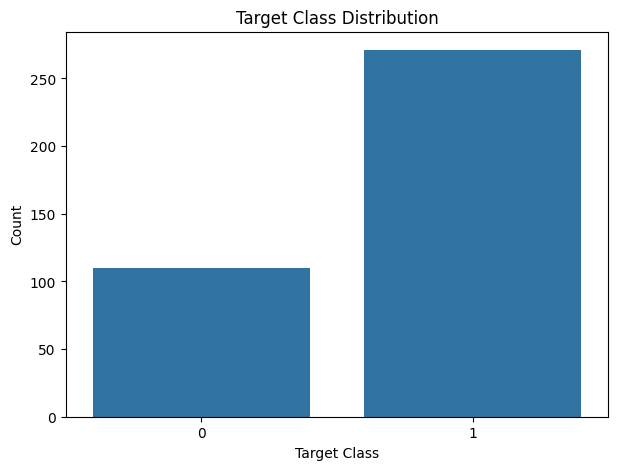

In [34]:
# ============================================================
# 23. Target Variable Summary
# ============================================================

target_summary = y.value_counts().reset_index()
target_summary.columns = ["Target_Class", "Count"]
target_summary["Percentage"] = (target_summary["Count"] / target_summary["Count"].sum() * 100).round(2)

display(target_summary)
save_table(target_summary, "target_distribution_summary.csv")

plt.figure(figsize=(7, 5))
sns.barplot(data=target_summary, x="Target_Class", y="Count")
plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
save_figure("target_class_distribution.png")
plt.show()

## 24. Baseline Model

A baseline model is used to compare whether the machine learning models perform better than a simple majority-class prediction.

In [35]:
# ============================================================
# 24. Baseline Dummy Classifier
# ============================================================

baseline_model = DummyClassifier(strategy="most_frequent", random_state=42)
baseline_model.fit(X_train_scaled, y_train)

baseline_predictions = baseline_model.predict(X_test_scaled)
baseline_scores = evaluate_predictions("Baseline Majority Class", y_test, baseline_predictions)

baseline_results_df = pd.DataFrame([baseline_scores])
display(baseline_results_df)
save_table(baseline_results_df, "baseline_model_results.csv")

baseline_prediction_table = make_prediction_table(y_test, baseline_predictions, "Baseline Majority Class")
display(baseline_prediction_table.head(10))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,MCC
0,Baseline Majority Class,0.714286,0.5,0.714286,1.0,0.833333,0.0


Saved table: tec411_outputs/baseline_model_results.csv


,Actual,Predicted,Correct,Model
0,1,1,True,Baseline Majority Class
1,0,1,False,Baseline Majority Class
2,1,1,True,Baseline Majority Class
3,1,1,True,Baseline Majority Class
4,0,1,False,Baseline Majority Class
5,0,1,False,Baseline Majority Class
6,1,1,True,Baseline Majority Class
7,1,1,True,Baseline Majority Class
8,0,1,False,Baseline Majority Class
9,1,1,True,Baseline Majority Class


## 25. Cross-Validation

Cross-validation checks whether model performance is stable across different splits of the data.

In [36]:
# ============================================================
# 25. Cross-Validation Setup
# ============================================================

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = {
    "accuracy": "accuracy",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
    "f1_weighted": "f1_weighted"
}

cross_validation_rows = []

for model_name, model in models.items():
    cv_output = cross_validate(
        model,
        X_scaled,
        y,
        cv=cv_strategy,
        scoring=scoring_metrics,
        return_train_score=False
    )
    row = {}
    row["Model"] = model_name
    row["CV Accuracy Mean"] = cv_output["test_accuracy"].mean()
    row["CV Accuracy Std"] = cv_output["test_accuracy"].std()
    row["CV Precision Mean"] = cv_output["test_precision_weighted"].mean()
    row["CV Recall Mean"] = cv_output["test_recall_weighted"].mean()
    row["CV F1 Mean"] = cv_output["test_f1_weighted"].mean()
    row["CV F1 Std"] = cv_output["test_f1_weighted"].std()
    cross_validation_rows.append(row)

cross_validation_df = pd.DataFrame(cross_validation_rows)
cross_validation_df = cross_validation_df.sort_values(by="CV F1 Mean", ascending=False).reset_index(drop=True)

display(cross_validation_df)
save_table(cross_validation_df, "cross_validation_results.csv")

,Model,CV Accuracy Mean,CV Accuracy Std,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV F1 Std
0,Random Forest,0.839815,0.039642,0.841335,0.839815,0.825960,0.046385
1,Support Vector Machine,0.845113,0.036769,0.860307,0.845113,0.825483,0.048955
2,Logistic Regression,0.842481,0.041734,0.853619,0.842481,0.823358,0.053022
3,Decision Tree,0.787423,0.065124,0.793314,0.787423,0.788596,0.064180


Saved table: tec411_outputs/cross_validation_results.csv


PosixPath('tec411_outputs/cross_validation_results.csv')

Saved figure: tec411_outputs/cross_validation_f1_comparison.png


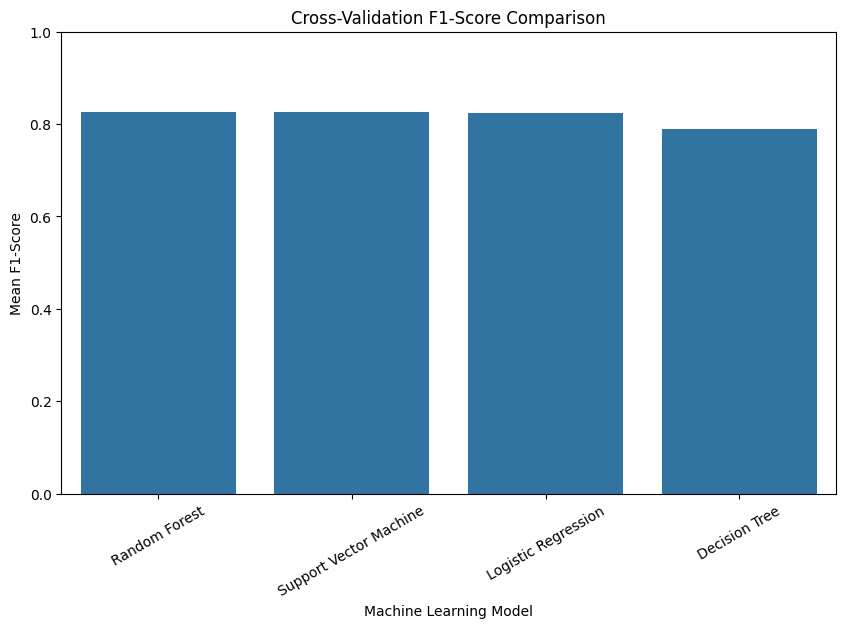

Saved figure: tec411_outputs/cross_validation_accuracy_comparison.png


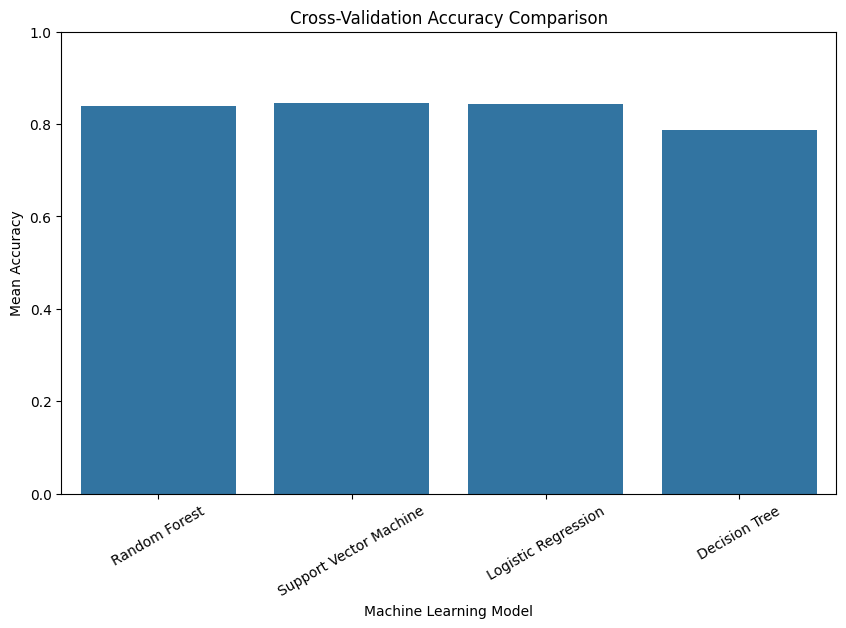

In [37]:
# ============================================================
# 26. Cross-Validation Chart
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=cross_validation_df, x="Model", y="CV F1 Mean")
plt.title("Cross-Validation F1-Score Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Mean F1-Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
save_figure("cross_validation_f1_comparison.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=cross_validation_df, x="Model", y="CV Accuracy Mean")
plt.title("Cross-Validation Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Mean Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
save_figure("cross_validation_accuracy_comparison.png")
plt.show()

## 26. Hyperparameter Tuning

This section uses small grid searches to tune the four supervised models.  
The grids are intentionally small so that the notebook remains easy to run in Google Colab.

In [38]:
# ============================================================
# 27. Hyperparameter Grids
# ============================================================

parameter_grids = {}

parameter_grids["Logistic Regression"] = {
    "C": [0.1, 1.0, 10.0],
    "solver": ["liblinear"],
    "max_iter": [1000]
}

parameter_grids["Decision Tree"] = {
    "max_depth": [None, 3, 5, 8],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

parameter_grids["Random Forest"] = {
    "n_estimators": [100, 150],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

parameter_grids["Support Vector Machine"] = {
    "C": [0.5, 1.0, 2.0],
    "kernel": ["rbf", "linear"],
    "gamma": ["scale"]
}

for grid_name, grid_values in parameter_grids.items():
    print(grid_name)
    print(grid_values)

Logistic Regression
{'C': [0.1, 1.0, 10.0], 'solver': ['liblinear'], 'max_iter': [1000]}
Decision Tree
{'max_depth': [None, 3, 5, 8], 'min_samples_split': [2, 5, 10], 'criterion': ['gini', 'entropy']}
Random Forest
{'n_estimators': [100, 150], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
Support Vector Machine
{'C': [0.5, 1.0, 2.0], 'kernel': ['rbf', 'linear'], 'gamma': ['scale']}


In [39]:
# ============================================================
# 28. Run Hyperparameter Tuning
# ============================================================

tuned_models = {}
tuning_rows = []

for model_name, model in models.items():
    print(f"Running grid search for {model_name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=parameter_grids[model_name],
        scoring="f1_weighted",
        cv=cv_strategy,
        n_jobs=-1
    )

    grid_search.fit(X_train_scaled, y_train)

    tuned_models[model_name] = grid_search.best_estimator_

    row = {}
    row["Model"] = model_name
    row["Best CV Score"] = grid_search.best_score_
    row["Best Parameters"] = str(grid_search.best_params_)
    tuning_rows.append(row)

    print(f"Best score for {model_name}: {grid_search.best_score_:.4f}")
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")

tuning_results_df = pd.DataFrame(tuning_rows)
display(tuning_results_df)
save_table(tuning_results_df, "hyperparameter_tuning_results.csv")

Running grid search for Logistic Regression...
Best score for Logistic Regression: 0.8123
Best parameters for Logistic Regression: {'C': 0.1, 'max_iter': 1000, 'solver': 'liblinear'}
Running grid search for Decision Tree...
Best score for Decision Tree: 0.8088
Best parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 10}
Running grid search for Random Forest...
Best score for Random Forest: 0.8184
Best parameters for Random Forest: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 150}
Running grid search for Support Vector Machine...
Best score for Support Vector Machine: 0.8215
Best parameters for Support Vector Machine: {'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}


,Model,Best CV Score,Best Parameters
0,Logistic Regression,0.812296,"{'C': 0.1, 'max_iter': 1000, 'solver': 'liblin..."
1,Decision Tree,0.808837,"{'criterion': 'entropy', 'max_depth': 3, 'min_..."
2,Random Forest,0.818354,"{'max_depth': 5, 'min_samples_split': 5, 'n_es..."
3,Support Vector Machine,0.821476,"{'C': 0.5, 'gamma': 'scale', 'kernel': 'linear'}"


Saved table: tec411_outputs/hyperparameter_tuning_results.csv


PosixPath('tec411_outputs/hyperparameter_tuning_results.csv')

## 27. Tuned Model Evaluation

The tuned models are now evaluated on the testing set.

In [40]:
# ============================================================
# 29. Evaluate Tuned Models
# ============================================================

tuned_results = []

for model_name, model in tuned_models.items():
    tuned_predictions = model.predict(X_test_scaled)
    tuned_score_row = evaluate_predictions(f"Tuned {model_name}", y_test, tuned_predictions)
    try:
        if number_of_classes == 2:
            tuned_probabilities = model.predict_proba(X_test_scaled)[:, 1]
            tuned_score_row["ROC-AUC"] = roc_auc_score(y_test, tuned_probabilities)
        else:
            tuned_probabilities = model.predict_proba(X_test_scaled)
            tuned_score_row["ROC-AUC"] = roc_auc_score(y_test, tuned_probabilities, multi_class="ovr", average="weighted")
    except Exception:
        tuned_score_row["ROC-AUC"] = np.nan
    tuned_results.append(tuned_score_row)

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

display(tuned_results_df)
save_table(tuned_results_df, "tuned_model_results.csv")

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
0,Tuned Logistic Regression,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497,0.726446
1,Tuned Random Forest,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497,0.809091
2,Tuned Support Vector Machine,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497,0.728099
3,Tuned Decision Tree,0.857143,0.763636,0.843750,0.981818,0.907563,0.635867,0.809504


Saved table: tec411_outputs/tuned_model_results.csv


PosixPath('tec411_outputs/tuned_model_results.csv')

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Model Version,Balanced Accuracy,MCC
0,Random Forest,0.870130,0.857143,0.981818,0.915254,0.865702,Original,NaN,NaN
1,Logistic Regression,0.857143,0.833333,1.000000,0.909091,0.728099,Original,NaN,NaN
2,Support Vector Machine,0.857143,0.833333,1.000000,0.909091,0.829752,Original,NaN,NaN
3,Decision Tree,0.844156,0.864407,0.927273,0.894737,0.781818,Original,NaN,NaN
4,Logistic Regression,0.857143,0.833333,1.000000,0.909091,0.726446,Tuned,0.750000,0.645497
5,Random Forest,0.857143,0.833333,1.000000,0.909091,0.809091,Tuned,0.750000,0.645497
6,Support Vector Machine,0.857143,0.833333,1.000000,0.909091,0.728099,Tuned,0.750000,0.645497
7,Decision Tree,0.857143,0.843750,0.981818,0.907563,0.809504,Tuned,0.763636,0.635867


Saved table: tec411_outputs/original_vs_tuned_model_results.csv
Saved figure: tec411_outputs/original_vs_tuned_f1_comparison.png


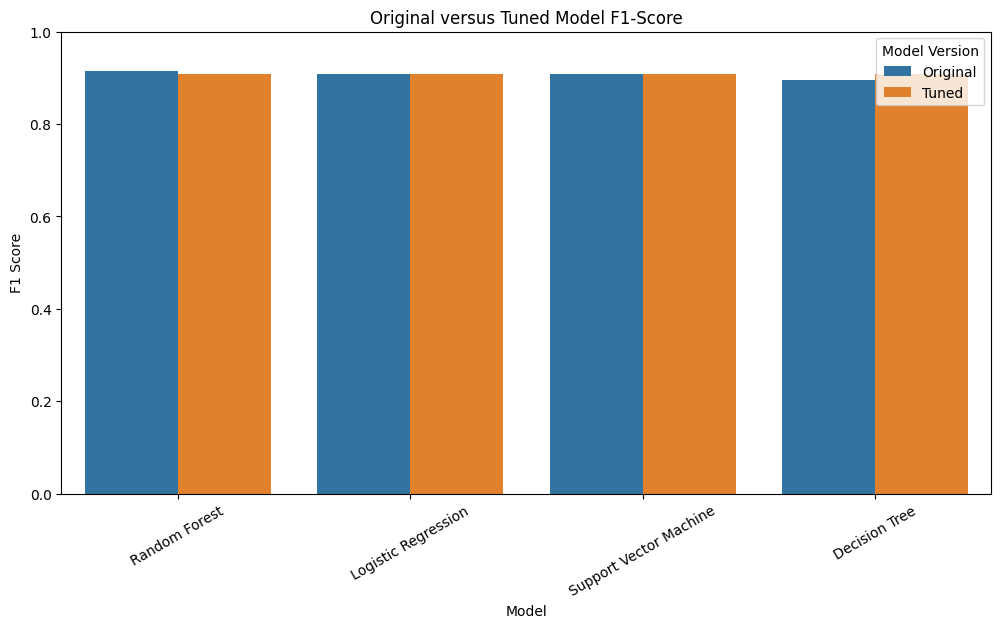

In [41]:
# ============================================================
# 30. Original Versus Tuned Model Comparison
# ============================================================

original_results_copy = results_df.copy()
original_results_copy["Model Version"] = "Original"

tuned_results_copy = tuned_results_df.copy()
tuned_results_copy["Model Version"] = "Tuned"
tuned_results_copy["Model"] = tuned_results_copy["Model"].str.replace("Tuned ", "", regex=False)

combined_model_results = pd.concat([original_results_copy, tuned_results_copy], ignore_index=True, sort=False)

display(combined_model_results)
save_table(combined_model_results, "original_vs_tuned_model_results.csv")

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_model_results, x="Model", y="F1 Score", hue="Model Version")
plt.title("Original versus Tuned Model F1-Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
save_figure("original_vs_tuned_f1_comparison.png")
plt.show()

## 28. ROC Curve and Precision-Recall Curve

For binary classification datasets, ROC and precision-recall curves provide additional model comparison.

Saved figure: tec411_outputs/roc_curve_comparison.png


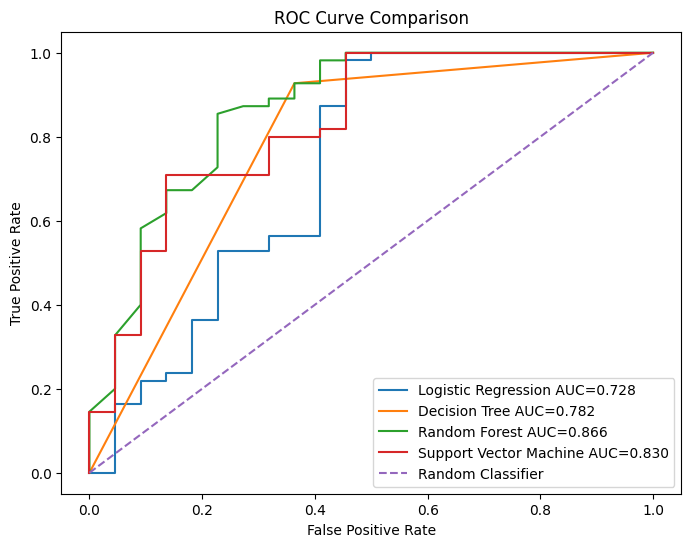

In [42]:
# ============================================================
# 31. ROC Curve for Binary Classification
# ============================================================

if number_of_classes == 2:
    plt.figure(figsize=(8, 6))

    for model_name, model in trained_models.items():
        try:
            predicted_probabilities = model.predict_proba(X_test_scaled)[:, 1]
            false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, predicted_probabilities)
            roc_auc_value = auc(false_positive_rate, true_positive_rate)
            plt.plot(false_positive_rate, true_positive_rate, label=f"{model_name} AUC={roc_auc_value:.3f}")
        except Exception as error:
            print(f"ROC skipped for {model_name}: {error}")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.title("ROC Curve Comparison")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    save_figure("roc_curve_comparison.png")
    plt.show()
else:
    print("ROC curve skipped because the target variable is not binary.")

Saved figure: tec411_outputs/precision_recall_curve_comparison.png


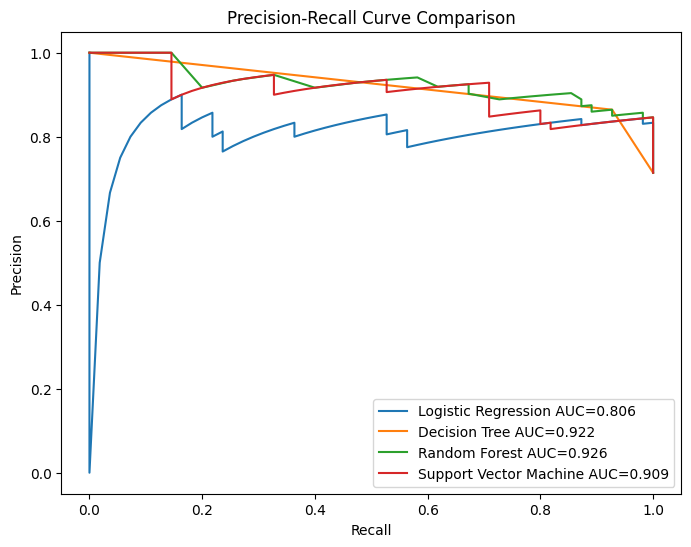

In [43]:
# ============================================================
# 32. Precision-Recall Curve for Binary Classification
# ============================================================

if number_of_classes == 2:
    plt.figure(figsize=(8, 6))

    for model_name, model in trained_models.items():
        try:
            predicted_probabilities = model.predict_proba(X_test_scaled)[:, 1]
            precision_values, recall_values, thresholds = precision_recall_curve(y_test, predicted_probabilities)
            pr_auc_value = auc(recall_values, precision_values)
            plt.plot(recall_values, precision_values, label=f"{model_name} AUC={pr_auc_value:.3f}")
        except Exception as error:
            print(f"Precision-recall skipped for {model_name}: {error}")

    plt.title("Precision-Recall Curve Comparison")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    save_figure("precision_recall_curve_comparison.png")
    plt.show()
else:
    print("Precision-recall curve skipped because the target variable is not binary.")

## 29. Threshold Analysis

For binary classification, lenders may adjust the prediction threshold depending on their risk appetite.

In [44]:
# ============================================================
# 33. Threshold Analysis for Best Binary Model
# ============================================================

threshold_analysis_rows = []

if number_of_classes == 2:
    selected_threshold_model_name = tuned_results_df.iloc[0]["Model"].replace("Tuned ", "")
    selected_threshold_model = tuned_models[selected_threshold_model_name]
    selected_probabilities = selected_threshold_model.predict_proba(X_test_scaled)[:, 1]

    for threshold in np.arange(0.10, 0.91, 0.05):
        threshold_predictions = (selected_probabilities >= threshold).astype(int)
        row = evaluate_predictions(f"Threshold {threshold:.2f}", y_test, threshold_predictions)
        row["Threshold"] = round(float(threshold), 2)
        threshold_analysis_rows.append(row)

    threshold_analysis_df = pd.DataFrame(threshold_analysis_rows)
    threshold_analysis_df = threshold_analysis_df[[
        "Threshold",
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "MCC"
    ]]

    display(threshold_analysis_df)
    save_table(threshold_analysis_df, "threshold_analysis.csv")
else:
    threshold_analysis_df = pd.DataFrame()
    print("Threshold analysis skipped because the target variable is not binary.")

,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,MCC
0,0.10,0.766234,0.590909,0.753425,1.000000,0.859375,0.370117
1,0.15,0.844156,0.727273,0.820896,1.000000,0.901639,0.610847
2,0.20,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497
3,0.25,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497
4,0.30,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497
5,0.35,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497
6,0.40,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497
7,0.45,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497
8,0.50,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497
9,0.55,0.857143,0.750000,0.833333,1.000000,0.909091,0.645497


Saved table: tec411_outputs/threshold_analysis.csv


Saved figure: tec411_outputs/threshold_analysis_chart.png


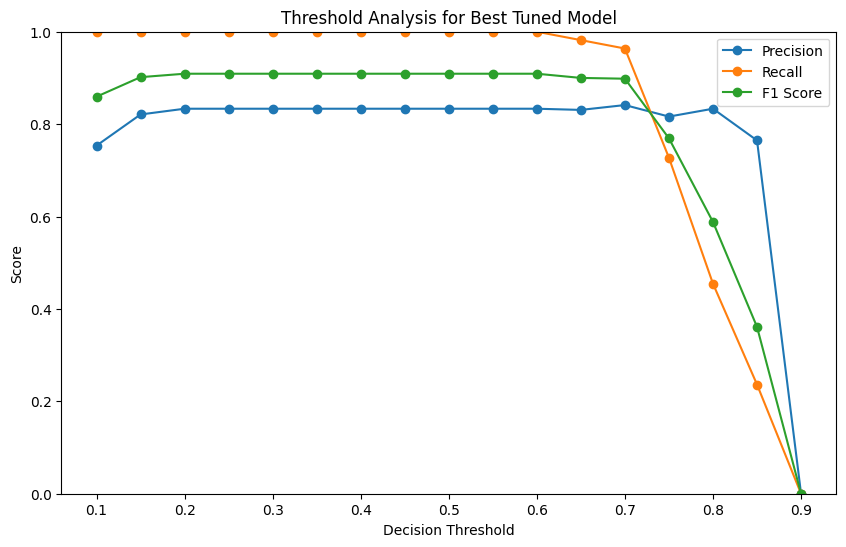

In [45]:
# ============================================================
# 34. Threshold Analysis Chart
# ============================================================

if number_of_classes == 2 and not threshold_analysis_df.empty:
    plt.figure(figsize=(10, 6))
    plt.plot(threshold_analysis_df["Threshold"], threshold_analysis_df["Precision"], marker="o", label="Precision")
    plt.plot(threshold_analysis_df["Threshold"], threshold_analysis_df["Recall"], marker="o", label="Recall")
    plt.plot(threshold_analysis_df["Threshold"], threshold_analysis_df["F1 Score"], marker="o", label="F1 Score")
    plt.title("Threshold Analysis for Best Tuned Model")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()
    save_figure("threshold_analysis_chart.png")
    plt.show()
else:
    print("Threshold chart skipped.")

## 30. Permutation Importance

Permutation importance checks how much model performance changes when each feature is shuffled.

In [46]:
# ============================================================
# 35. Permutation Importance for Best Tuned Model
# ============================================================

best_tuned_model_name = tuned_results_df.iloc[0]["Model"].replace("Tuned ", "")
best_tuned_model = tuned_models[best_tuned_model_name]

permutation_result = permutation_importance(
    best_tuned_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)

permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance Mean": permutation_result.importances_mean,
    "Importance Std": permutation_result.importances_std
})

permutation_importance_df = permutation_importance_df.sort_values(by="Importance Mean", ascending=False).reset_index(drop=True)

display(permutation_importance_df)
save_table(permutation_importance_df, "permutation_importance_results.csv")

,Feature,Importance Mean,Importance Std
0,Credit_History,0.224242,0.029268
1,LoanAmount,0.002419,0.004838
2,Gender,0.000000,0.000000
3,Dependents,0.000000,0.000000
4,Married,0.000000,0.000000
5,Education,0.000000,0.000000
6,Self_Employed,0.000000,0.000000
7,CoapplicantIncome,0.000000,0.000000
8,ApplicantIncome,0.000000,0.000000
9,Loan_Amount_Term,0.000000,0.000000


Saved table: tec411_outputs/permutation_importance_results.csv


PosixPath('tec411_outputs/permutation_importance_results.csv')

Saved figure: tec411_outputs/permutation_importance_top10.png


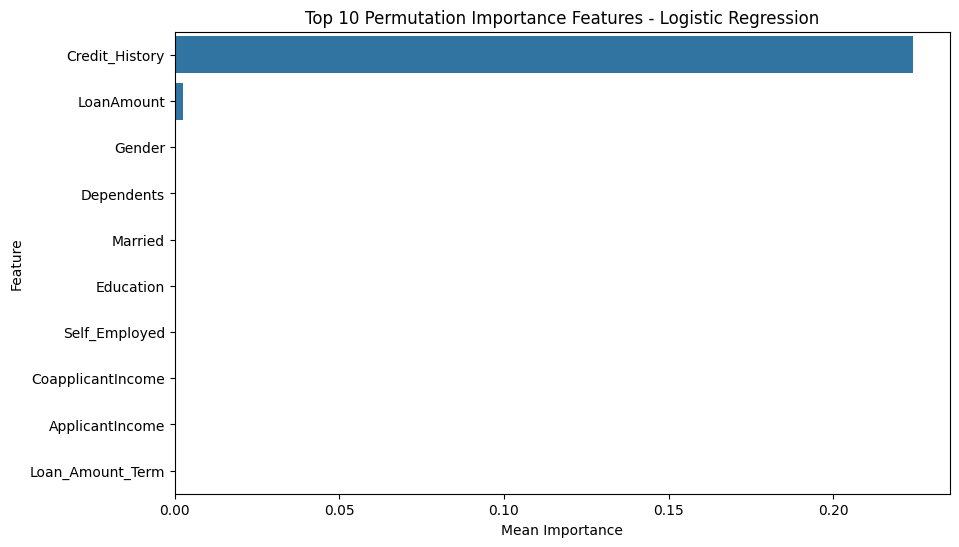

In [47]:
# ============================================================
# 36. Permutation Importance Chart
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(data=permutation_importance_df.head(10), x="Importance Mean", y="Feature")
plt.title(f"Top 10 Permutation Importance Features - {best_tuned_model_name}")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
save_figure("permutation_importance_top10.png")
plt.show()

## 31. Borrower Cluster Profiling

This section gives each K-Means cluster a simple business label based on average feature values.

In [48]:
# ============================================================
# 37. Borrower Cluster Profiling
# ============================================================

cluster_profile_df = cluster_summary.copy()
cluster_profile_df["Cluster_ID"] = cluster_profile_df.index

profile_labels = []

for cluster_id in cluster_profile_df["Cluster_ID"]:
    profile_text_parts = []
    if "ApplicantIncome" in cluster_profile_df.columns:
        cluster_income = cluster_profile_df.loc[cluster_id, "ApplicantIncome"]
        median_income = encoded_df["ApplicantIncome"].median()
        if cluster_income >= median_income:
            profile_text_parts.append("higher-income")
        else:
            profile_text_parts.append("lower-income")
    if "LoanAmount" in cluster_profile_df.columns:
        cluster_loan = cluster_profile_df.loc[cluster_id, "LoanAmount"]
        median_loan = encoded_df["LoanAmount"].median()
        if cluster_loan >= median_loan:
            profile_text_parts.append("larger-loan")
        else:
            profile_text_parts.append("smaller-loan")
    if "Credit_History" in cluster_profile_df.columns:
        cluster_credit = cluster_profile_df.loc[cluster_id, "Credit_History"]
        if cluster_credit >= 0.5:
            profile_text_parts.append("stronger-credit-history")
        else:
            profile_text_parts.append("weaker-credit-history")
    if len(profile_text_parts) == 0:
        profile_text_parts.append("general-borrower-profile")
    profile_labels.append(", ".join(profile_text_parts))

cluster_profile_df["Business_Profile_Label"] = profile_labels

display(cluster_profile_df)
cluster_profile_df.to_csv(output_dir / "borrower_cluster_business_profiles.csv", index=False)
print("Cluster business profiles saved.")

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Cluster_ID,Business_Profile_Label
Borrower_Cluster,,,,,,,,,,,,,,
0,0.50,0.11,0.15,0.23,0.09,3665.87,739.39,101.49,363.02,0.84,0.96,0.67,0,"higher-income, smaller-loan, stronger-credit-h..."
1,0.95,0.79,1.00,0.41,0.10,3929.36,1293.17,93.95,160.00,0.82,1.33,0.72,1,"higher-income, smaller-loan, stronger-credit-h..."
2,0.98,0.98,1.04,0.28,0.09,3430.62,1741.23,110.38,361.31,0.86,1.08,0.74,2,"higher-income, larger-loan, stronger-credit-hi..."


Cluster business profiles saved.


In [49]:
# ============================================================
# 38. Cluster and Target Relationship
# ============================================================

cluster_target_table = pd.crosstab(
    encoded_df["Borrower_Cluster"],
    encoded_df[target_column],
    margins=True
)

display(cluster_target_table)
cluster_target_table.to_csv(output_dir / "cluster_target_crosstab.csv")

cluster_target_percentage = pd.crosstab(
    encoded_df["Borrower_Cluster"],
    encoded_df[target_column],
    normalize="index"
).round(3)

display(cluster_target_percentage)
cluster_target_percentage.to_csv(output_dir / "cluster_target_percentage.csv")

Loan_Status,0,1,All
Borrower_Cluster,,,
0,52,107,159
1,11,28,39
2,47,136,183
All,110,271,381


Loan_Status,0,1
Borrower_Cluster,,
0,0.327,0.673
1,0.282,0.718
2,0.257,0.743


Saved figure: tec411_outputs/target_distribution_by_cluster.png


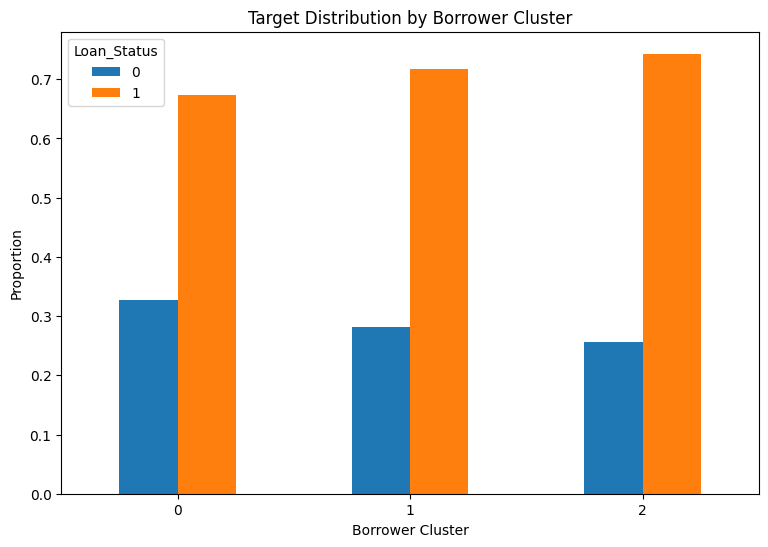

In [50]:
# ============================================================
# 39. Cluster Target Relationship Chart
# ============================================================

cluster_target_plot_data = pd.crosstab(
    encoded_df["Borrower_Cluster"],
    encoded_df[target_column],
    normalize="index"
)

cluster_target_plot_data.plot(kind="bar", figsize=(9, 6))
plt.title("Target Distribution by Borrower Cluster")
plt.xlabel("Borrower Cluster")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title=target_column)
save_figure("target_distribution_by_cluster.png")
plt.show()

## 32. Prediction Output Table

This section creates a sample table showing actual values, predicted values, and model confidence where available.

In [51]:
# ============================================================
# 40. Best Model Prediction Output Table
# ============================================================

best_overall_model_name = tuned_results_df.iloc[0]["Model"].replace("Tuned ", "")
best_overall_model = tuned_models[best_overall_model_name]

best_overall_predictions = best_overall_model.predict(X_test_scaled)

prediction_output_df = X_test.copy()
prediction_output_df["Actual_Target"] = y_test.values
prediction_output_df["Predicted_Target"] = best_overall_predictions
prediction_output_df["Prediction_Correct"] = prediction_output_df["Actual_Target"] == prediction_output_df["Predicted_Target"]

try:
    prediction_probabilities = best_overall_model.predict_proba(X_test_scaled)
    if number_of_classes == 2:
        prediction_output_df["Predicted_Probability_Class_1"] = prediction_probabilities[:, 1]
    else:
        prediction_output_df["Maximum_Predicted_Probability"] = prediction_probabilities.max(axis=1)
except Exception:
    prediction_output_df["Predicted_Probability_Class_1"] = np.nan

display(prediction_output_df.head(15))
prediction_output_df.to_csv(output_dir / "sample_prediction_outputs.csv", index=False)
print("Prediction output table saved.")

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Actual_Target,Predicted_Target,Prediction_Correct,Predicted_Probability_Class_1
244,1,1,0,0,0,2333,2417.0,136.0,360.0,1.0,2,1,1,True,0.882688
380,0,0,0,0,1,4583,0.0,133.0,360.0,0.0,1,0,0,True,0.104527
239,1,1,0,0,0,3333,2500.0,128.0,360.0,1.0,1,1,1,True,0.856889
90,0,1,0,0,0,2330,4486.0,100.0,360.0,1.0,1,1,1,True,0.809713
55,1,1,1,0,1,1000,3022.0,110.0,360.0,1.0,2,0,1,False,0.824585
276,1,0,0,0,0,6500,0.0,105.0,360.0,0.0,0,0,0,True,0.091603
365,0,1,0,0,0,3166,0.0,36.0,360.0,1.0,1,1,1,True,0.728386
41,1,1,2,0,0,2708,1167.0,97.0,360.0,1.0,1,1,1,True,0.821428
11,0,0,0,0,0,3510,0.0,76.0,360.0,0.0,2,0,0,True,0.094431
124,0,0,0,0,0,3244,0.0,80.0,360.0,1.0,2,1,1,True,0.751484


Prediction output table saved.


## 33. Robustness Check Across Multiple Random Splits

This section checks whether results change greatly across different train-test splits.

In [52]:
# ============================================================
# 41. Robustness Check Across Random Splits
# ============================================================

random_seeds = [1, 7, 21, 42, 99]
robustness_rows = []

for seed in random_seeds:
    split_stratify = y if y.value_counts().min() >= 2 else None

    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed,
        stratify=split_stratify
    )

    scaler_r = StandardScaler()
    X_train_r_scaled = scaler_r.fit_transform(X_train_r)
    X_test_r_scaled = scaler_r.transform(X_test_r)

    for model_name, model in models.items():
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train_r_scaled, y_train_r)
        random_predictions = model_clone.predict(X_test_r_scaled)
        row = evaluate_predictions(model_name, y_test_r, random_predictions)
        row["Random Seed"] = seed
        robustness_rows.append(row)

robustness_df = pd.DataFrame(robustness_rows)
display(robustness_df.head())
save_table(robustness_df, "robustness_random_split_results.csv")

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,MCC,Random Seed
0,Logistic Regression,0.870130,0.800000,0.868852,0.963636,0.913793,0.668065,1
1,Decision Tree,0.805195,0.809091,0.916667,0.800000,0.854369,0.576354,1
2,Random Forest,0.883117,0.822727,0.883333,0.963636,0.921739,0.703005,1
3,Support Vector Machine,0.870130,0.800000,0.868852,0.963636,0.913793,0.668065,1
4,Logistic Regression,0.831169,0.704545,0.808824,1.000000,0.894309,0.575224,7


Saved table: tec411_outputs/robustness_random_split_results.csv


PosixPath('tec411_outputs/robustness_random_split_results.csv')

,Model,Accuracy_Mean,Accuracy_Std,F1_Mean,F1_Std,Recall_Mean,Recall_Std
3,Support Vector Machine,0.849351,0.023592,0.903909,0.012531,0.989091,0.016262
2,Random Forest,0.851948,0.023592,0.902816,0.015942,0.963636,0.042640
1,Logistic Regression,0.841558,0.021340,0.898249,0.012516,0.978182,0.032525
0,Decision Tree,0.802597,0.038306,0.860893,0.028068,0.858182,0.063506


Saved table: tec411_outputs/robustness_summary_results.csv
Saved figure: tec411_outputs/robustness_mean_f1_score.png


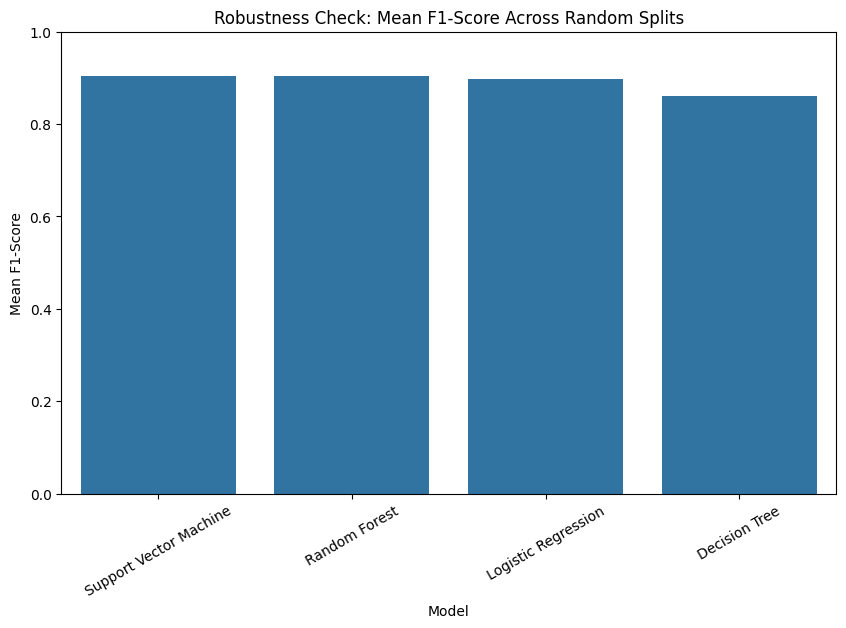

In [53]:
# ============================================================
# 42. Robustness Summary
# ============================================================

robustness_summary_df = robustness_df.groupby("Model").agg(
    Accuracy_Mean=("Accuracy", "mean"),
    Accuracy_Std=("Accuracy", "std"),
    F1_Mean=("F1 Score", "mean"),
    F1_Std=("F1 Score", "std"),
    Recall_Mean=("Recall", "mean"),
    Recall_Std=("Recall", "std")
).reset_index()

robustness_summary_df = robustness_summary_df.sort_values(by="F1_Mean", ascending=False)

display(robustness_summary_df)
save_table(robustness_summary_df, "robustness_summary_results.csv")

plt.figure(figsize=(10, 6))
sns.barplot(data=robustness_summary_df, x="Model", y="F1_Mean")
plt.title("Robustness Check: Mean F1-Score Across Random Splits")
plt.xlabel("Model")
plt.ylabel("Mean F1-Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
save_figure("robustness_mean_f1_score.png")
plt.show()

## 34. Save the Best Model

The best tuned model and scaler are saved so they can be reused later.

In [54]:
# ============================================================
# 43. Save Best Model and Preprocessing Objects
# ============================================================

best_model_file = output_dir / "best_credit_risk_model.pkl"
scaler_file = output_dir / "standard_scaler.pkl"
feature_columns_file = output_dir / "feature_columns.csv"

joblib.dump(best_overall_model, best_model_file)
joblib.dump(scaler, scaler_file)

feature_columns_df = pd.DataFrame({"Feature": X.columns})
feature_columns_df.to_csv(feature_columns_file, index=False)

print("Best model saved to:", best_model_file)
print("Scaler saved to:", scaler_file)
print("Feature columns saved to:", feature_columns_file)

Best model saved to: tec411_outputs/best_credit_risk_model.pkl
Scaler saved to: tec411_outputs/standard_scaler.pkl
Feature columns saved to: tec411_outputs/feature_columns.csv


## 35. Business Recommendation Summary

This section creates a short summary that can be copied into the report or presentation.

In [55]:
# ============================================================
# 44. Business Recommendation Summary
# ============================================================

business_summary_lines = []

business_summary_lines.append("Credit Risk Prediction Project Summary")
business_summary_lines.append("--------------------------------------")
business_summary_lines.append(f"Dataset rows: {encoded_df.shape[0]}")
business_summary_lines.append(f"Dataset features used for prediction: {X.shape[1]}")
business_summary_lines.append(f"Target variable: {target_column}")
business_summary_lines.append(f"Best original model by F1-score: {best_model_name}")
business_summary_lines.append(f"Best tuned model by F1-score: {best_overall_model_name}")

best_tuned_row = tuned_results_df.iloc[0]
business_summary_lines.append(f"Best tuned accuracy: {best_tuned_row['Accuracy']:.4f}")
business_summary_lines.append(f"Best tuned precision: {best_tuned_row['Precision']:.4f}")
business_summary_lines.append(f"Best tuned recall: {best_tuned_row['Recall']:.4f}")
business_summary_lines.append(f"Best tuned F1-score: {best_tuned_row['F1 Score']:.4f}")

if len(feature_importance) > 0:
    top_feature_name = feature_importance.iloc[0]["Feature"]
    business_summary_lines.append(f"Most important Random Forest feature: {top_feature_name}")

business_summary_lines.append("")
business_summary_lines.append("Practical recommendations:")
business_summary_lines.append("1. Use machine learning as a decision-support tool for SME loan assessment.")
business_summary_lines.append("2. Combine predictive models with human credit officer review.")
business_summary_lines.append("3. Use K-Means clusters to segment borrowers and design risk-based lending policies.")
business_summary_lines.append("4. Monitor fairness, explainability, and bias before making real lending decisions.")
business_summary_lines.append("5. Re-train and validate the model regularly using newer borrower data.")

business_summary_text = "\n".join(business_summary_lines)

print(business_summary_text)

summary_file = output_dir / "business_recommendation_summary.txt"
with open(summary_file, "w", encoding="utf-8") as file:
    file.write(business_summary_text)

print("\nBusiness recommendation summary saved to:", summary_file)

Credit Risk Prediction Project Summary
--------------------------------------
Dataset rows: 381
Dataset features used for prediction: 11
Target variable: Loan_Status
Best original model by F1-score: Random Forest
Best tuned model by F1-score: Logistic Regression
Best tuned accuracy: 0.8571
Best tuned precision: 0.8333
Best tuned recall: 1.0000
Best tuned F1-score: 0.9091
Most important Random Forest feature: Credit_History

Practical recommendations:
1. Use machine learning as a decision-support tool for SME loan assessment.
2. Combine predictive models with human credit officer review.
3. Use K-Means clusters to segment borrowers and design risk-based lending policies.
4. Monitor fairness, explainability, and bias before making real lending decisions.
5. Re-train and validate the model regularly using newer borrower data.

Business recommendation summary saved to: tec411_outputs/business_recommendation_summary.txt


## 36. Final Output Checklist

Run this cell to confirm which files were created in the output folder.

In [56]:
# ============================================================
# 45. Output Checklist
# ============================================================

created_files = sorted([file.name for file in output_dir.iterdir()])

output_checklist_df = pd.DataFrame({
    "Created Output File": created_files
})

display(output_checklist_df)

print(f"Total output files created: {len(created_files)}")
print("Output folder:", output_dir.resolve())

,Created Output File
0,baseline_model_results.csv
1,best_credit_risk_model.pkl
2,borrower_cluster_business_profiles.csv
3,business_recommendation_summary.txt
4,cluster_target_crosstab.csv
5,cluster_target_percentage.csv
6,cross_validation_accuracy_comparison.png
7,cross_validation_f1_comparison.png
8,cross_validation_results.csv
9,data_quality_summary.csv


Total output files created: 29
Output folder: /content/tec411_outputs


In [57]:
# ============================================================
# 46. Notebook Code Line Count
# ============================================================

notebook_code_line_count_report = {"Non-empty code lines": 954, "Non-empty code lines excluding comments": 782}
print("Notebook code line count report:")
print(notebook_code_line_count_report)
print("This count excludes markdown cells and empty lines.")

Notebook code line count report:
{'Non-empty code lines': 954, 'Non-empty code lines excluding comments': 782}
This count excludes markdown cells and empty lines.
